In [1]:
%matplotlib inline

In [2]:
import os
from pathlib import Path

import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

import xarray as xr

from scipy.special import erf
from numpy import pi as π

In [3]:
# trig functions that take degrees

def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# Make input directory

In [4]:
Path('./INPUT').mkdir(exist_ok=True)

# Create grid

In [77]:
grid = 'isotropic'

xw = 0
xe = 30
ys = 10
dx = 0.5

xq = np.arange(xw, xe+dx, dx)
xh = np.arange(xw+dx/2, xe, dx)

NX = len(xh)

if grid == 'latlon':
    yn = 45

    dy = 0.5

    yq = np.arange(ys, yn+dy, dy)
    yh = np.arange(ys+dy/2, yn, dy)
    NY = len(yh)
elif grid == 'isotropic': # aka Mercator
    NY = 81
    
    jh = np.arange(NY) + .5
    jq = np.arange(NY+1)

    yq = np.rad2deg(2*np.arctan(np.exp(jq*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
    yh = np.rad2deg(2*np.arctan(np.exp(jh*np.deg2rad(dx))*np.tan(π/4 + np.deg2rad(ys)/2)) - π/2)
else:
    RuntimeError('unknown grid type')
    
    
dyq = a*np.deg2rad(np.diff(yh))
dyh = a*np.deg2rad(np.diff(yq))
dxq = a*np.deg2rad(dx)*cosd(yq)
dxh = a*np.deg2rad(dx)*cosd(yh)

Aq = dxq[1:-1]*dyq

# Layer configuration

In [128]:
# number of layers
NK = 2

# maximum depth

# interface depths
eta = np.array([
       0,
    -131,
  -12000, # the last entry can be anything as long as it's deeper than the basin
], dtype=float) 

interface_IC = xr.Dataset(
    {'eta': (['nki'], eta, {'long_name': 'Initial depth of interfaces', 'units': 'meters'})},
)

interface_IC.to_netcdf('INPUT/interface_IC.nc')

In [129]:
interface_IC

<xarray.Dataset>
Dimensions:  (nki: 3)
Dimensions without coordinates: nki
Data variables:
    eta      (nki) float64 0.0 -131.0 -1.2e+04

# Topography - Erf-like shelves on eastern and western boundaries

## Case I: constant width in degrees

In [39]:
geolon, geolat = np.meshgrid(xh, yh)

λe = 30 # longitude of eastern boundary

Hshelf = 100 # shelf depth
Hmax = 4000

Lshelf = 1.5 # shelf width in degrees
Lslope = 1.5 # slope width in degrees

def H0(λ):
    return Hshelf + 0.5*(Hmax - Hshelf)*(1 + erf(np.sqrt(π)*((λ - Lshelf)/Lslope - 0.5)))

H = H0(geolon) + H0(λe - geolon) - Hmax

In [40]:
topog = xr.Dataset(coords={'yh': (['yh'], yh), 'xh': (['xh'], xh)})

topog['depth'] = (['yh', 'xh'], H, {'long_name': 'Ocean Depth', 'units': 'm'})

topog.to_netcdf('INPUT/topog_degrees.nc')

topog

<xarray.Dataset>
Dimensions:  (xh: 60, yh: 81)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
Data variables:
    depth    (yh, xh) float64 101.6 123.8 284.7 886.7 ... 284.7 123.8 101.6

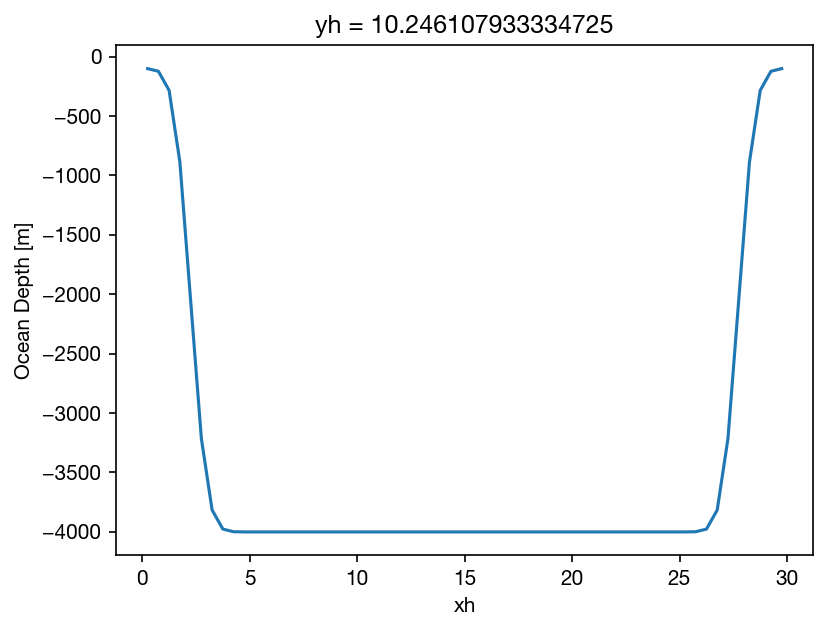

In [44]:
(-topog.depth).isel(yh=0).plot()

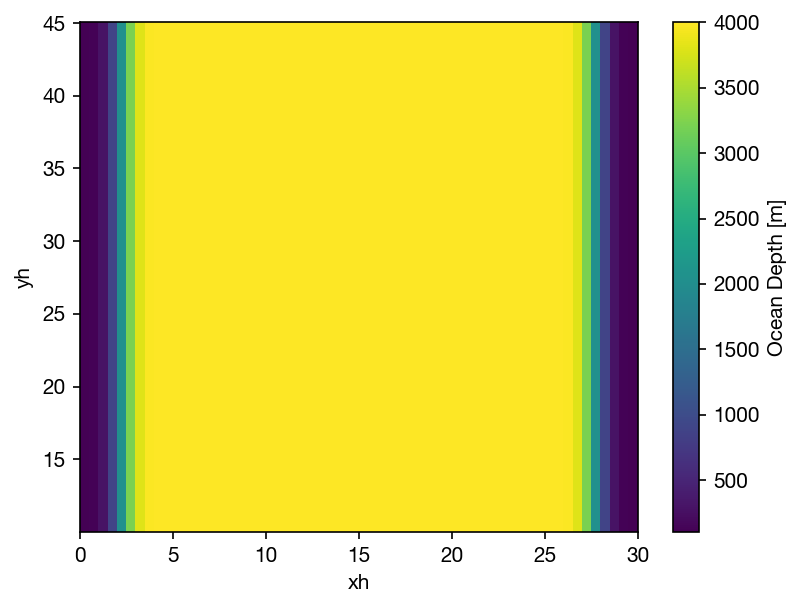

In [45]:
topog.depth.plot()

# Wind forcing

The wind forcing is

$$
    \tau^x = \tau_0 \cos\pi \frac{\vartheta - \vartheta_0}{\vartheta_0 - \vartheta_s},
$$
where $\vartheta_0 = 35^\circ$ and $\vartheta_s = 15^\circ$. The wind stress curl is zero at $\vartheta_0$, but the Ekman pumping goes to zero slightly south of this, at $\vartheta = 33.5^\circ$.

In [110]:
τ0 = 0.10

θs = 15
θ0 = 35
θn = θ0 + (θ0 - θs)/2
θp = 33.5

def tau_def(y):
#     breakpoint()
    θ = np.atleast_1d(np.array(y, dtype=float))
    tau = np.zeros_like(θ)
    
    idx = θ >= θs
    tau[idx] = τ0*np.cos(π*(θ[idx] - θ0)/(θ0-θs))    
    tau[~idx] = -τ0
    
    return tau

In [115]:
taux = np.repeat(tau_def(yh)[:,np.newaxis], NX+1, axis=1)
tauy = np.zeros((NY+1, NX))

a = 6370e3
ρ0 = 1035
Ω = 7.29e-5

f = 2*Ω*sind(yh)
fq = 2*Ω*sind(yq)
β = 2*Ω*cosd(yh)/a
βq = 2*Ω*cosd(yq)/a
Lx = a*np.deg2rad(xe-xw)*cosd(yh)
Lxq = a*np.deg2rad(xe-xw)*cosd(yq)


# net Ekman transport
Vek = -Lxh*tau_def(yh)/f/ρ0

# Sverdrup transport
wsc = -np.diff(dxh*tau_def(yh))/Aq
Vsv = (Lxq/βq)[1:-1]*wsc/ρ0

# net geostrophic transport
wEk = -np.diff(dxh*tau_def(yh)/f/ρ0)/Aq
Vg = (Lxq*fq/βq)[1:-1]*wEk

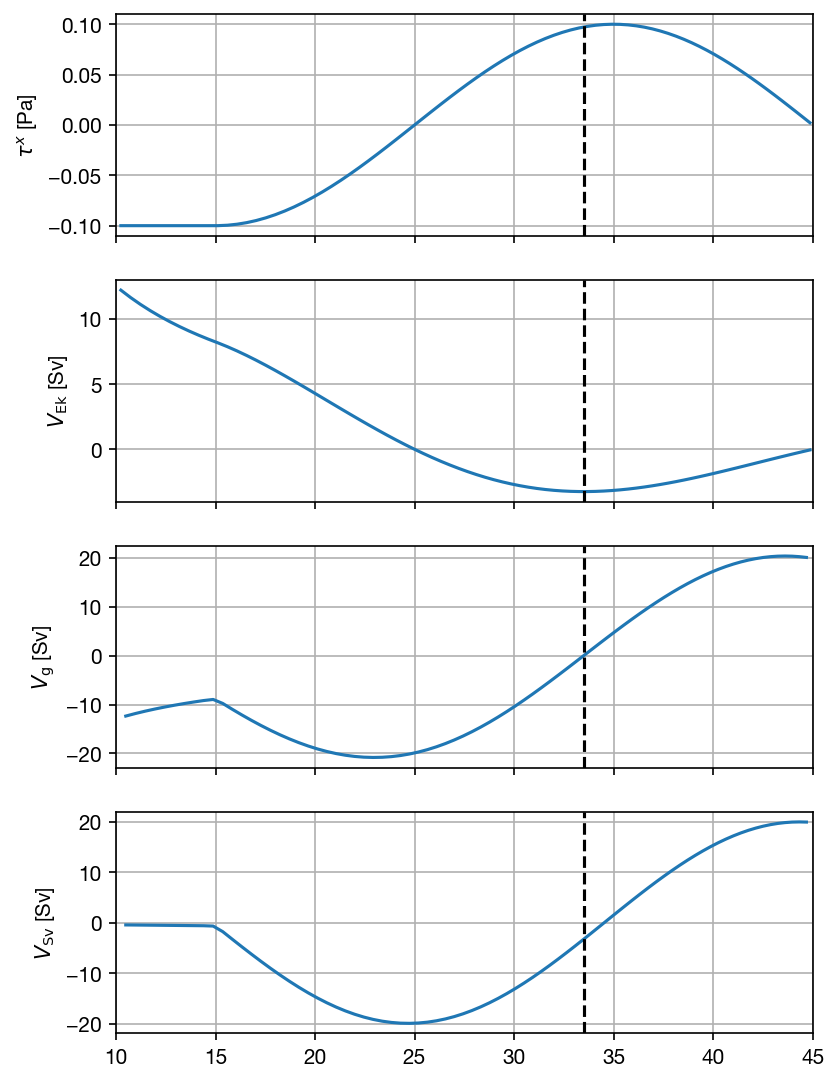

In [116]:
fig, axs = plt.subplots(nrows=4, sharex=True, figsize=(6, 9))

ax = axs[0]
ax.plot(yh, taux[:,0])
ax.set_ylabel(r'$\tau^x$ [Pa]')

ax = axs[1]
ax.plot(yh, Vek/1e6)
ax.set_ylabel(r'$V_\mathrm{Ek}$ [Sv]')

ax = axs[2]
ax.plot(yq[1:-1], Vg/1e6, '-')
ax.set_ylabel(r'$V_\mathrm{g}$ [Sv]')

ax = axs[3]
ax.plot(yq[1:-1], Vsv/1e6)
ax.set_ylabel(r'$V_\mathrm{Sv}$ [Sv]')

ax.set_xlim([yq[0], yq[-1]])

for ax in axs:
    ax.axvline(33.5, ls='--', color='k')
    ax.grid()

At $\theta = 33.5$ the interior geostrophic transport vanishes but the Ekman transport doesn't. The thermocline will be flat at this latitude and all the transport will be carried by the western boundary current. Assuming a geostrophic WBC, the depth of the thermocline on the western boundary will be 

$$
    h_w = \sqrt{h_e^2 + \frac{2f}{g'}V_\mathrm{Ek}},
$$

where $V_\mathrm{Ek}$ is the zonally integrated Ekman transport:

$$
    V_\mathrm{Ek} = -\frac{\tau^x L_x}{\rho_0 f}.
$$

Thermodynamic arguments suggest that the thermocline should outcrop at this point, which suggests we choose the eastern boundary depth to be
$$
    h_e = \sqrt{-\frac{2f}{g'}V_\mathrm{Ek}} = \sqrt{\frac{2 \tau^x L_x}{\rho_0 g'}}
$$

If we also suppose we want a fixed baroclinic wave speed

$$
    c_0 = \sqrt{g' h_e},
$$

we can constrain both the thermocline depth and the reduced gravity:

$$
\begin{aligned}
    h_e &= \frac{2\tau^x L_x}{\rho_0 c_0^2},  &   g' &= \frac{\rho_0 c_0^4}{2 \tau^x L_x}.
\end{aligned}
$$

Chelton et al. (1998) suggests that $c_0 = 2.0$ m s$^{-1}$ is a good value for the boundary between the subtropical and subpolar gyres in the Atlantic. With the parameters $L_x = 2781$ km, $\tau^x = 0.097$ Pa, and $\rho_0 = 1035$ kg m$^{-3}$, this works out to $h_e = 131$ m and $g' = 0.031$ m s$^{-2}$.

In [131]:
c0 = 2
Lx0 = a*np.deg2rad(xe-xw)*cosd(θp)
he = 2*Lx0*tau_def(θp)/ρ0/c0**2
gp = ρ0*c0**4/(2*Lx0*tau_def(θp))

print(he, gp)

[130.64891725] [0.0306164]


In [134]:
# MOM6 expects xq and yq to have be missing the last point
forcing = xr.Dataset(coords={
    'yh': (['yh'], yh), 
    'xh': (['xh'], xh),
    'yq': (['yq'], yq[:-1]), 
    'xq': (['xq'], xq[:-1]),
})

forcing['STRESS_X'] = (['yh', 'xq'], taux[:,:-1], {'long_name': 'Zonal Momentum Flux', 'units': 'Pa'})
forcing['STRESS_Y'] = (['yq', 'xh'], tauy[:-1,:], {'long_name': 'Meridional Momentum Flux', 'units': 'Pa'})

forcing.to_netcdf('INPUT/forcing.nc')

forcing

<xarray.Dataset>
Dimensions:   (yh: 81, xh: 60, yq: 81, xq: 60)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
Data variables:
    STRESS_X  (yh, xq) float64 -0.1 -0.1 -0.1 -0.1 ... 0.0022 0.0022 0.0022
    STRESS_Y  (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

Read back in after running the model to make sure it took

In [21]:
ds = xr.open_dataset('forcing__0001_003.nc')
forcing_diag = ds
ds.close()

<xarray.Dataset>
Dimensions:     (Time: 2, nv: 2, xq: 61, yh: 100)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.75 11.25 11.75 ... 58.25 58.75 59.25 59.75
  * Time        (Time) object 0001-01-03 12:00:00 0001-01-08 12:00:00
  * nv          (nv) float64 1.0 2.0
Data variables:
    taux        (Time, yh, xq) float32 ...
    average_T1  (Time) object ...
    average_T2  (Time) object ...
    average_DT  (Time) timedelta64[ns] ...
    Time_bnds   (Time, nv) timedelta64[ns] ...
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

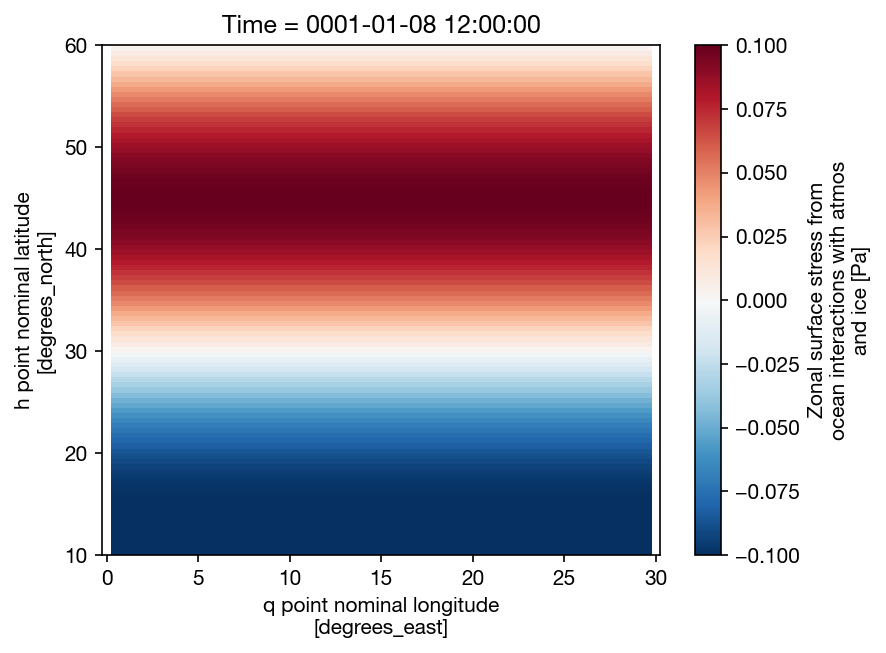

In [23]:
forcing_diag.taux.isel(Time=-1).plot()